## Below is the code to recreate Figure 8.

Topic: Showing the simulated Upper Sco cluster (via best-fit isochrone) against actual data from UKIDSS.

In [1]:
# Importing necessary packages.
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import numpy as np
import pandas as pd
import pylab as py
import pdb
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, vstack
%matplotlib inline
%load_ext autoreload
%autoreload

In [2]:
# simulate Upper Sco-like cluster (mass=1000-2000 M_sun, distance=145 pc, extinction=2)
    # age= 5 myr, z = 0.015, per paper (Alfonso et al., 2023)

In [3]:
# Define isochrone parameters
logAge = np.log10(5*1e6) # Age in log(years)
AKs = 0.05 # extinction in mags
dist = 145 # distance in parsec
metallicity = 0 # Metallicity in [M/H]

# Define evolution/atmosphere models and extinction law
evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec() 
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawHosek18b()

# Specify UKIDSS filters
ukidss_filts = ['ukirt,J', 'ukirt,H', 'ukirt,K']

# Specify the directory we want the output isochrone
# table saved in. If the directory does not already exist,
# SPISEA will create it.
iso_dir = 'isochrones/'

# Make IsochronePhot object. Note that this will take a minute or two, 
# unless the isochrone has been generated previously.
#
# Note that this is not show all of the user options 
# for IsochronePhot. See docs for complete list of options.
my_iso = synthetic.IsochronePhot(logAge, AKs, dist, metallicity=0,
                            evo_model=evo_model, atm_func=atm_func,
                            red_law=red_law, filters=ukidss_filts,
                                iso_dir=iso_dir, recomp=True)

Changing to logg=5.00 for T=  1614 logg=3.86
Changing to logg=5.00 for T=  1734 logg=3.90
Changing to logg=5.00 for T=  1844 logg=3.94
Changing to logg=5.00 for T=  1939 logg=3.96
Changing to logg=4.00 for T= 32651 logg=3.99
Changing to logg=4.00 for T= 32840 logg=3.98
Changing to logg=4.00 for T= 33037 logg=3.97
Changing to logg=4.00 for T= 33144 logg=3.96
Changing to logg=4.00 for T= 33205 logg=3.95
Changing to logg=4.00 for T= 33358 logg=3.94
Changing to logg=4.00 for T= 33504 logg=3.93
Changing to logg=4.00 for T= 33651 logg=3.91
Changing to logg=4.00 for T= 33713 logg=3.91
Changing to logg=4.00 for T= 33775 logg=3.90
Changing to logg=4.00 for T= 33892 logg=3.89
Changing to logg=4.00 for T= 34002 logg=3.87
Changing to logg=4.00 for T= 34111 logg=3.86
Changing to logg=4.00 for T= 34182 logg=3.85
Changing to logg=4.00 for T= 34222 logg=3.85
Changing to logg=4.00 for T= 34332 logg=3.83
Changing to logg=4.00 for T= 34443 logg=3.82
Changing to logg=4.00 for T= 34546 logg=3.81
Changing t

In [4]:
m = my_iso.points['mass']

phillips = (m < 0.07) & (m >= 0.01)
phillips_baraffe = (m >= 0.07) & (m < 0.075)

baraffe = (m >= 0.075) & (m < 0.4)
baraffe_pisa = (m >= 0.4) & (m < 0.5)

pisa = (m >= 0.5) & (m < 7.0)
ms = m >= 7.0   # Ekstrom at this age

color = my_iso.points['m_ukirt_J'] - my_iso.points['m_ukirt_K']
mag   = my_iso.points['m_ukirt_J']

In [5]:
# plotting simulated Upper Sco cluster
imf_multi = multiplicity.MultiplicityUnresolved()
my_imf = imf.Salpeter_Kirkpatrick_2024(multiplicity=imf_multi)

mass = 1500.
# Make cluster object
cluster = synthetic.ResolvedCluster(my_iso, my_imf, mass)

clust = cluster.star_systems
iso = my_iso.points

mask = (my_iso.points['mass'] >= 0.009)

# Look at the cluster CMD, compared to input isochrone. Note the impact of
# multiple systems on the photometry
clust = cluster.star_systems
iso = my_iso.points[mask]

Found 1 stars out of mass range


In [6]:
# read in ukidss data
other = '/System/Volumes/Data/mnt/g3/scratch/caitlinbegbie/code/SPISEA/changes/asu (3).fit'
tab = Table.read(other, format='fits', hdu=2)
tab

focus = np.where((tab['Jmag'] - tab['Kmag'] < 10))
minus = tab['Jmag'] - tab['Kmag']
J_K = minus[focus]

j_err = tab['e_Jmag']
k_err = tab['e_Kmag']
jk_err = np.sqrt(j_err**2 + k_err**2)

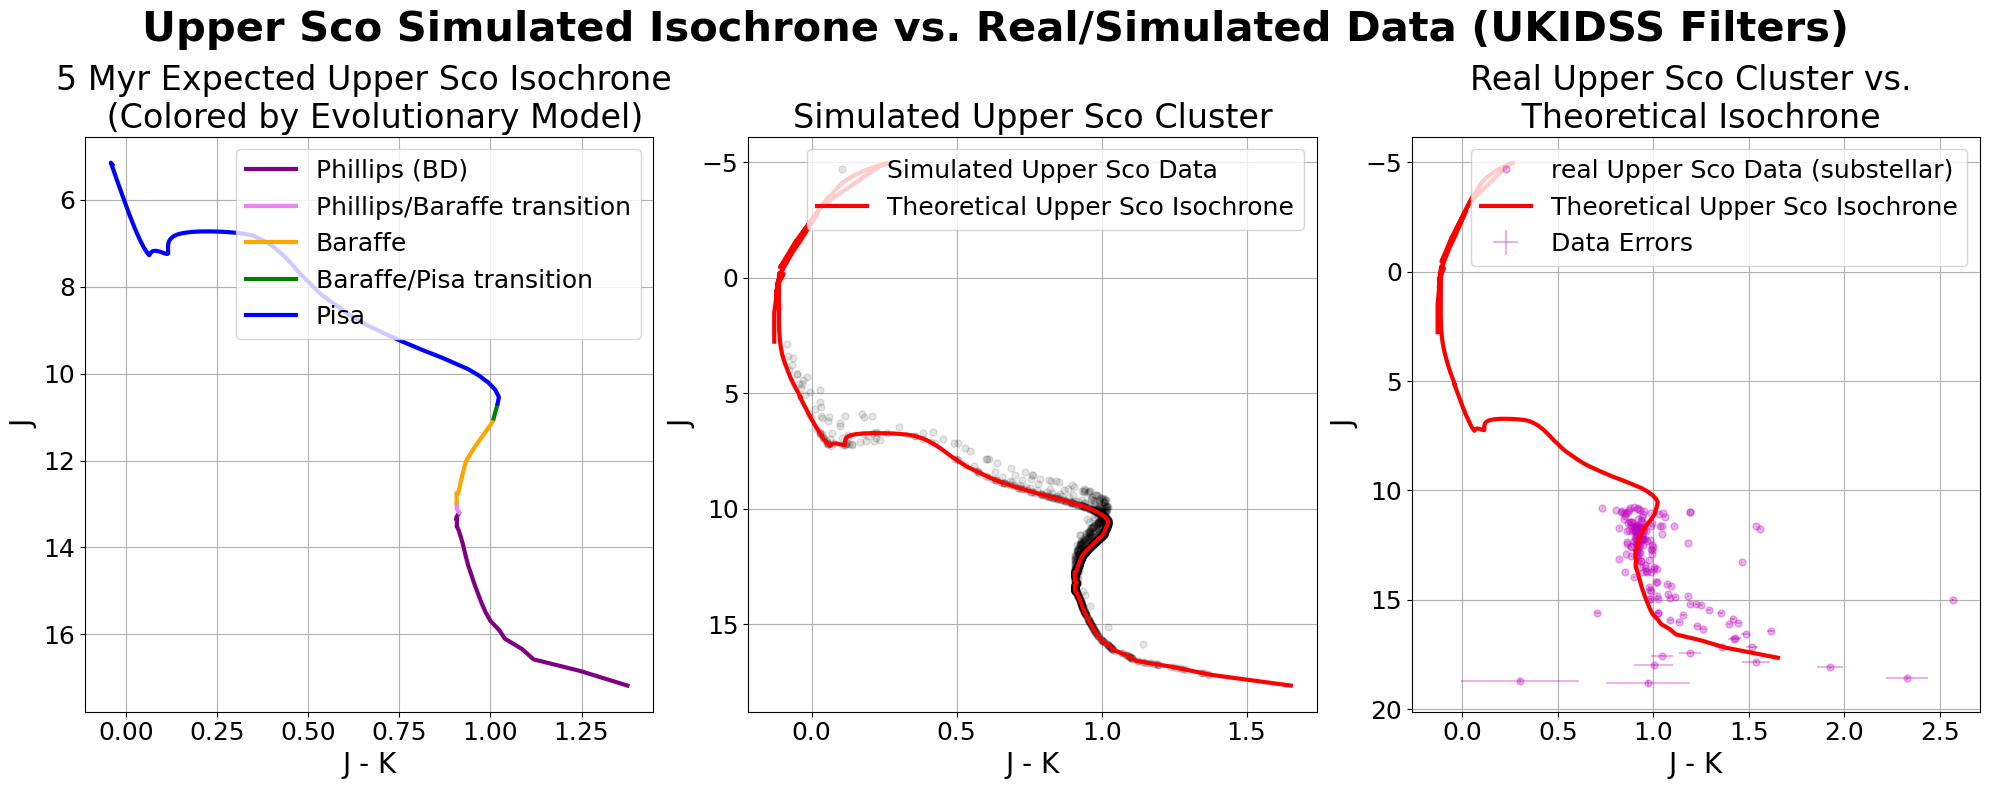

In [7]:
# Plotting all together
fig, axs = plt.subplots(1, 3, figsize=(20,8))

plt.suptitle('Upper Sco Simulated Isochrone vs. Real/Simulated Data (UKIDSS Filters)', fontsize=30, fontweight='bold')

axs[0].plot(color[phillips], mag[phillips], '-', color='purple', label='Phillips (BD)', linewidth=3)
axs[0].plot(color[phillips_baraffe], mag[phillips_baraffe], '-', color='violet', label='Phillips/Baraffe transition', linewidth=3)
axs[0].plot(color[baraffe], mag[baraffe], '-', color='orange', label='Baraffe', linewidth=3)
axs[0].plot(color[baraffe_pisa], mag[baraffe_pisa], '-', color='green', label='Baraffe/Pisa transition', linewidth=3)
axs[0].plot(color[pisa], mag[pisa], '-', color='blue', label='Pisa', linewidth=3)
#axs[0].plot(color[ms], mag[ms], '-', color='red', label='Ekstrom MS', linewidth=3)
axs[0].invert_yaxis()
axs[0].set_xlabel('J - K', fontsize=20)
axs[0].set_ylabel('J', fontsize=20)
axs[0].set_title('5 Myr Expected Upper Sco Isochrone \n (Colored by Evolutionary Model)', fontsize=24)
axs[0].legend(markerscale=4, fontsize=18, loc='upper right')
axs[0].tick_params(axis='both', labelsize=18)
axs[0].grid()

axs[1].plot(clust['m_ukirt_J'] - clust['m_ukirt_K'], clust['m_ukirt_J'],
       'k.', ms=10, alpha=0.1, label='Simulated Upper Sco Data')
axs[1].plot(my_iso.points['m_ukirt_J'][mask] - my_iso.points['m_ukirt_K'][mask], 
       my_iso.points['m_ukirt_J'][mask],
       'r-', linewidth=3, label='Theoretical Upper Sco Isochrone')
axs[1].set_xlabel('J - K', fontsize=20)
axs[1].set_ylabel('J', fontsize=20)
axs[1].invert_yaxis()
axs[1].set_title('Simulated Upper Sco Cluster', fontsize=24)
axs[1].legend(fontsize=18, loc='upper right')
axs[1].tick_params(axis='both', labelsize=18)
axs[1].grid()

axs[2].plot(J_K, tab['Jmag'][focus],
       'm.', ms=10, alpha=0.3, label='real Upper Sco Data (substellar)')
axs[2].errorbar(J_K, tab['Jmag'][focus], xerr=jk_err[focus], yerr=j_err[focus], color='m', fmt='none', ms=5, alpha=0.3, label='Data Errors')
axs[2].plot(my_iso.points['m_ukirt_J'][mask] - my_iso.points['m_ukirt_K'][mask], 
       my_iso.points['m_ukirt_J'][mask],
       'r-', linewidth=3, label='Theoretical Upper Sco Isochrone')
axs[2].set_xlabel('J - K', fontsize=20)
axs[2].set_ylabel('J', fontsize=20)
axs[2].invert_yaxis()
axs[2].set_title('Real Upper Sco Cluster vs. \n Theoretical Isochrone', fontsize=24)
axs[2].legend(fontsize=18, loc='upper right')
axs[2].tick_params(axis='both', labelsize=18)
axs[2].grid()

plt.tight_layout()
plt.savefig('uppersco_ukidss.png')
plt.show()